<a href="https://colab.research.google.com/github/Naveen-gale/ml-part-4/blob/main/titani_ml_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
from google.colab import files
file = files.upload()

Saving tested.csv to tested.csv


In [8]:
import pandas as pd
df = pd.read_csv("tested.csv")

In [9]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [12]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [15]:
df.shape

(418, 12)

In [17]:
df.nunique()

,0
PassengerId,418
Survived,2
Pclass,3
Name,418
Sex,2
Age,79
SibSp,7
Parch,8
Ticket,363
Fare,169


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


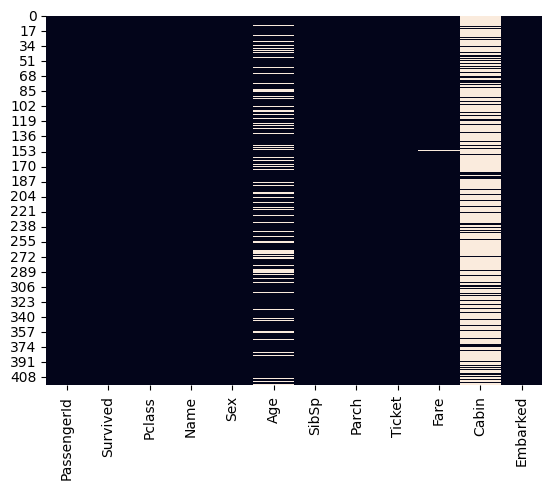

In [21]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [22]:
df["Age"]= df["Age"].fillna(df['Age'].median())

In [29]:
df= df.drop("Cabin", axis=1)

In [30]:
df["Fare"]= df["Fare"].fillna(df['Fare'].mean())

In [31]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: xlabel='Survived', ylabel='count'>

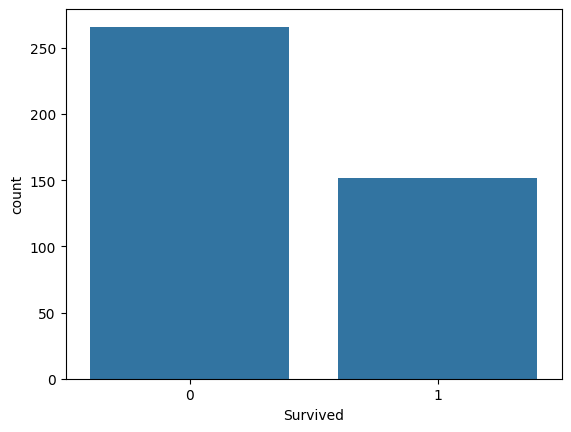

In [33]:
sns.countplot(x="Survived", data=df)

<Axes: xlabel='Sex', ylabel='count'>

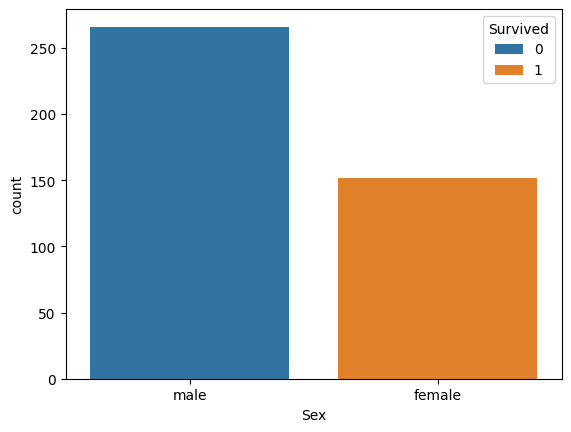

In [35]:
sns.countplot(x='Sex', hue='Survived', data=df)

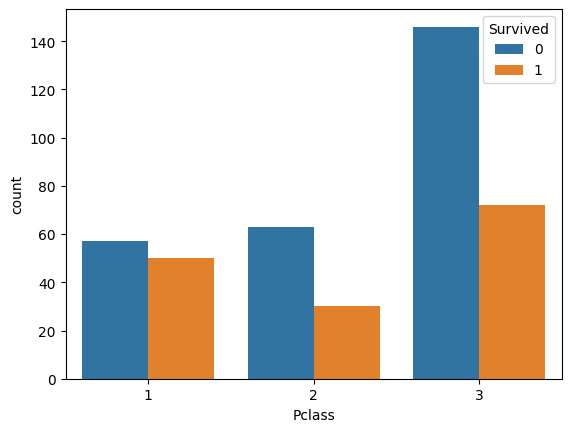

In [36]:
sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.show()

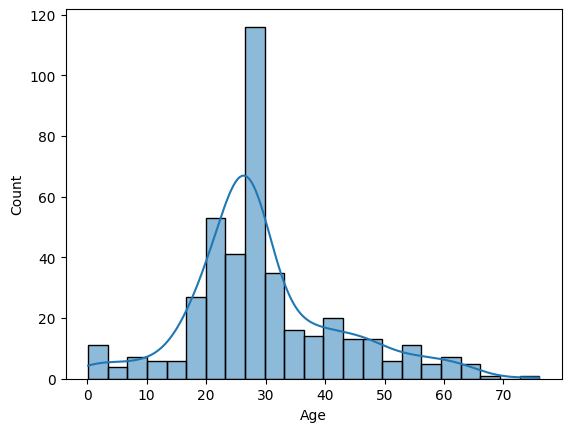

In [37]:
sns.histplot(df['Age'], kde=True)

plt.show()

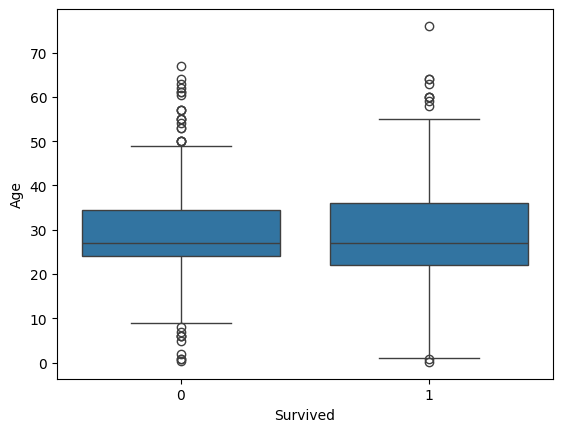

In [38]:
sns.boxplot(
    x='Survived',
    y='Age',
    data=df
)

plt.show()

AttributeError: 'DataFrame' object has no attribute 'heatmap'

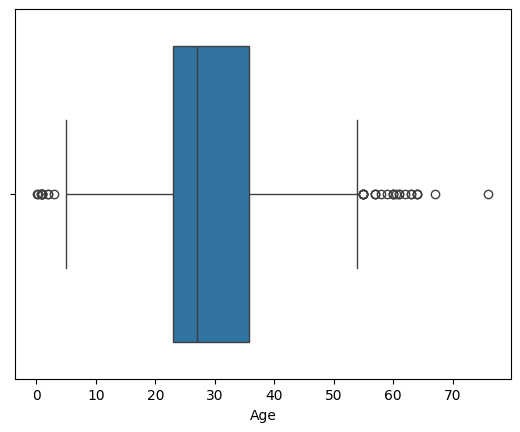

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Age'])
plt.show()

In [42]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [43]:
df = df.drop(['PassengerId', 'Name', 'Ticket'], axis=1)

In [44]:
df['Sex']= df['Sex'].map({
    'male': 0,
    'female':1
})

In [45]:
df['Sex'].head()

,Sex
0,0
1,1
2,0
3,0
4,1


In [49]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,34.5,0,0,7.8292,False,True,False
1,1,3,1,47.0,1,0,7.0000,False,False,True
2,0,2,0,62.0,0,0,9.6875,False,True,False
3,0,3,0,27.0,0,0,8.6625,False,False,True
4,1,3,1,22.0,1,1,12.2875,False,False,True


In [51]:
df= pd.get_dummies(df, columns=['Embarked_C'], drop_first=True )

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Survived         418 non-null    int64  
 1   Pclass           418 non-null    int64  
 2   Sex              418 non-null    int64  
 3   Age              418 non-null    float64
 4   SibSp            418 non-null    int64  
 5   Parch            418 non-null    int64  
 6   Fare             418 non-null    float64
 7   Embarked_Q       418 non-null    bool   
 8   Embarked_S       418 non-null    bool   
 9   Embarked_C_True  418 non-null    bool   
dtypes: bool(3), float64(2), int64(5)
memory usage: 24.2 KB


In [55]:
df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)
df['Embarked_C_True'] = df['Embarked_C_True'].astype(int)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Survived         418 non-null    int64  
 1   Pclass           418 non-null    int64  
 2   Sex              418 non-null    int64  
 3   Age              418 non-null    float64
 4   SibSp            418 non-null    int64  
 5   Parch            418 non-null    int64  
 6   Fare             418 non-null    float64
 7   Embarked_Q       418 non-null    int64  
 8   Embarked_S       418 non-null    int64  
 9   Embarked_C_True  418 non-null    int64  
dtypes: float64(2), int64(8)
memory usage: 32.8 KB


In [57]:
X= df.drop('Survived', axis=1)
y= df['Survived']

In [58]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S,Embarked_C_True
0,0,3,0,34.5,0,0,7.8292,1,0,0
1,1,3,1,47.0,1,0,7.0000,0,1,0
2,0,2,0,62.0,0,0,9.6875,1,0,0
3,0,3,0,27.0,0,0,8.6625,0,1,0
4,1,3,1,22.0,1,1,12.2875,0,1,0


In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
print(X_train.shape)
print(X_test.shape)


(334, 9)
(84, 9)


In [68]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.linear_model import LogisticRegression


In [72]:
model = LogisticRegression(
    C=1.0,
    class_weight=None,
    dual=False,
    max_iter=100
)
model.fit(X_train, y_train)

LogisticRegression()

In [73]:
y_pred= model.predict(X_test)

In [74]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

1.0